In [1]:
## STEP 1 IMPORT LIBRARY

import os
import pandas as pd
import numpy as np
import librosa
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score,
                             classification_report)
import warnings
warnings.filterwarnings('ignore')

In [2]:
## STEP 2 LOAD DATASET

# Path ke file metadata dan folder audio
metadata_path = 'validated.tsv'
audio_folder = 'clips'

# Membaca metadata
df = pd.read_csv(metadata_path, sep='\t')
print(f"Jumlah data awal: {len(df)}")
print(df.head())

Jumlah data awal: 30331
                                           client_id  \
0  00f046cd1abd7e4ed354c2d97b67aceee8deb20bf53e5c...   
1  018b3f1a0a941a5b881a886830d9f133402ed66409489a...   
2  025f07759891360d312521dd83679fa6a233b9d7aa9d4a...   
3  0a4e7e60acc2a6145fc2589e6abb81e41e430cea0611bd...   
4  0a64c046530244b7507d4404575e8f673613c939ad6fac...   

                           path  \
0  common_voice_id_39599471.mp3   
1  common_voice_id_32165882.mp3   
2  common_voice_id_27657418.mp3   
3  common_voice_id_23033570.mp3   
4  common_voice_id_40088845.mp3   

                                         sentence_id  \
0  05e82b3c6f238b34985f158c4b63a8a9fda0382f1bd798...   
1  dd457d82f974202742803bf426f129d339fb1cf2217876...   
2  34f56b62e91fbbffeb7df499d4486aaa9f6d963a93d57f...   
3  ecee266f978e8296fc17d2bcfa744429165db882dbe5fd...   
4  67125efffe8d90c1147d6d609ca9e041f17b1a78b6a3d2...   

                                            sentence  sentence_domain  \
0                D

In [3]:
## STEP 3 FILTER DATASET

# Filter hanya dua kelas yang diinginkan
df_filtered = df[df['gender'].isin(['male_masculine', 'female_feminine'])].copy()
print(f"Jumlah data setelah filter: {len(df_filtered)}")
print("Distribusi gender:")
print(df_filtered['gender'].value_counts())

Jumlah data setelah filter: 21587
Distribusi gender:
gender
male_masculine     13983
female_feminine     7604
Name: count, dtype: int64


In [4]:
## STEP 4 VALIDATE AUDIO FILES

# Daftar path file audio yang valid
valid_paths = []
for idx, row in df_filtered.iterrows():
    audio_path = os.path.join(audio_folder, row['path'])
    if os.path.exists(audio_path):
        valid_paths.append(idx)

df_filtered = df_filtered.loc[valid_paths].reset_index(drop=True)
print(f"Jumlah data setelah validasi file: {len(df_filtered)}")

Jumlah data setelah validasi file: 21587


In [5]:
##STEP 5 Menentukan parameter eksperimen

# Parameter eksperimen
N_MFCC = 24          # M4
K = 3                # K1

print(f"Eksperimen: MFCC={N_MFCC}, K={K}")

Eksperimen: MFCC=24, K=3


In [6]:
## STEP 6 Menentukan parameter audio

TARGET_SR = 16000
PRE_EMPHASIS = 0.97

# Parameter framing
FRAME_LENGTH_MS = 25
HOP_LENGTH_MS = 10

# Konversi milidetik ke jumlah sample
WIN_LENGTH = int(
    TARGET_SR * FRAME_LENGTH_MS / 1000
)

HOP_LENGTH = int(
    TARGET_SR * HOP_LENGTH_MS / 1000
)

# FFT
N_FFT = 512

print(f"Target Sample Rate : {TARGET_SR} Hz")
print(f"Pre-emphasis       : {PRE_EMPHASIS}")
print(f"MFCC               : {N_MFCC}")
print(f"K                  : {K}")
print(f"Frame Length       : {FRAME_LENGTH_MS} ms ({WIN_LENGTH} samples)")
print(f"Hop Length         : {HOP_LENGTH_MS} ms ({HOP_LENGTH} samples)")
print(f"N FFT              : {N_FFT}")

Target Sample Rate : 16000 Hz
Pre-emphasis       : 0.97
MFCC               : 24
K                  : 3
Frame Length       : 25 ms (400 samples)
Hop Length         : 10 ms (160 samples)
N FFT              : 512


In [7]:
### STEP 7 EKSTRAKSI FITUR MFCC

def extract_mfcc(
    file_path,
    n_mfcc=13,
    target_sr=16000,
    pre_emphasis=0.97,
    win_length=400,
    hop_length=160,
    n_fft=512
):
    try:

        # ==========================================
        # 1. LOAD AUDIO
        # ==========================================
        # Resampling ke 16 kHz
        # Mono = True memastikan audio menjadi mono

        y, sr = librosa.load(
            file_path,
            sr=target_sr,
            mono=True
        )

        # ==========================================
        # 2. PRE-EMPHASIS
        # ==========================================

        y = np.append(
            y[0],
            y[1:] - pre_emphasis * y[:-1]
        )

        # ==========================================
        # 3. EKSTRAKSI MFCC
        # ==========================================

        mfcc = librosa.feature.mfcc(
            y=y,
            sr=sr,
            n_mfcc=n_mfcc,
            n_fft=n_fft,
            win_length=win_length,
            hop_length=hop_length
        )

        # ==========================================
        # 4. RATA-RATA MFCC
        # ==========================================

        mfcc_mean = np.mean(
            mfcc,
            axis=1
        )

        return mfcc_mean

    except Exception as e:

        print(
            f"Error pada file {file_path}: {e}"
        )

        return None

In [8]:
##STEP 7 Ekstrak fitur untuk semua file audio
from tqdm import tqdm

X = []
y = []

for idx, row in df_filtered.iterrows():

    audio_path = os.path.join(
        audio_folder,
        row['path']
    )

    features = extract_mfcc(
        audio_path,
        n_mfcc=N_MFCC,
        target_sr=TARGET_SR,
        pre_emphasis=PRE_EMPHASIS,
        win_length=WIN_LENGTH,
        hop_length=HOP_LENGTH,
        n_fft=N_FFT
    )

    if features is not None:

        X.append(features)
        y.append(row['gender'])

# Konversi ke numpy array
X = np.array(X)
y = np.array(y)

print(
    f"Jumlah fitur yang berhasil diekstrak: "
    f"{X.shape[0]}"
)

print(
    f"Dimensi fitur: "
    f"{X.shape[1]}"
)

Jumlah fitur yang berhasil diekstrak: 21587
Dimensi fitur: 24


In [9]:
##STEP 8 Distribusi label setelah ekstraksi

unique, counts = np.unique(
    y,
    return_counts=True
)

print("Distribusi label setelah ekstraksi:")

for label, count in zip(
    unique,
    counts
):

    print(f"{label}: {count}")

Distribusi label setelah ekstraksi:
female_feminine: 7604
male_masculine: 13983


In [10]:
## STEP 9 Encode label

le = LabelEncoder()

y_encoded = le.fit_transform(y)

print(
    "Label mapping:"
)

print(
    dict(
        zip(
            le.classes_,
            le.transform(le.classes_)
        )
    )
)

Label mapping:
{np.str_('female_feminine'): np.int64(0), np.str_('male_masculine'): np.int64(1)}


In [11]:
##STEP 10 Split data menjadi training dan testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded
)

print(
    f"Training set size: "
    f"{X_train.shape[0]}"
)

print(
    f"Testing set size: "
    f"{X_test.shape[0]}"
)

Training set size: 17269
Testing set size: 4318


In [12]:
## STEP 11 Standarisasi fitur

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print("Standarisasi selesai.")

Standarisasi selesai.


In [13]:
## STEP 12 Buat model KNN

knn = KNeighborsClassifier(
    n_neighbors=K
)

print(
    f"Model KNN dengan K={K} dibuat."
)

Model KNN dengan K=3 dibuat.


In [14]:
##STEP 13 Latih model KNN

knn.fit(
    X_train_scaled,
    y_train
)

print("Training selesai.")

Training selesai.


In [15]:
##STEP 14 Prediksi pada data testing

y_pred = knn.predict(
    X_test_scaled
)

print("Prediksi selesai.")

Prediksi selesai.


In [16]:
## STEP 15 Evaluasi model

# CONFUSION MATRIX
# ==========================================
cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)


# ==========================================
# METRICS
# ==========================================

acc = accuracy_score(
    y_test,
    y_pred
)

prec = precision_score(
    y_test,
    y_pred,
    average='binary'
)

rec = recall_score(
    y_test,
    y_pred,
    average='binary'
)

f1 = f1_score(
    y_test,
    y_pred,
    average='binary'
)


print(f"\nAccuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-Score  : {f1:.4f}")


# ==========================================
# CLASSIFICATION REPORT
# ==========================================

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=le.classes_
    )
)

Confusion Matrix:
[[1497   24]
 [  12 2785]]

Accuracy  : 0.9917
Precision : 0.9915
Recall    : 0.9957
F1-Score  : 0.9936

Classification Report:
                 precision    recall  f1-score   support

female_feminine       0.99      0.98      0.99      1521
 male_masculine       0.99      1.00      0.99      2797

       accuracy                           0.99      4318
      macro avg       0.99      0.99      0.99      4318
   weighted avg       0.99      0.99      0.99      4318



In [17]:
##STEP 16 Tampilkan hasil eksperimen

print("\n=== HASIL EKSPERIMEN ===")
print(f"MFCC = {N_MFCC}, K = {K}")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-Score  : {f1:.4f}")
print("Confusion Matrix:")
print(cm)


=== HASIL EKSPERIMEN ===
MFCC = 24, K = 3
Accuracy  : 0.9917
Precision : 0.9915
Recall    : 0.9957
F1-Score  : 0.9936
Confusion Matrix:
[[1497   24]
 [  12 2785]]


Jumlah data unknown awal: 8744
Jumlah data unknown setelah validasi file: 8744
Jumlah fitur unknown yang berhasil diekstrak: 8744
Total data gabungan: 30331
Distribusi label: female=7604, male=13983, unknown=8744
Jumlah komponen PCA: 24
Varians terkumpul: 1.0000
Ukuran data t-SNE: 30331


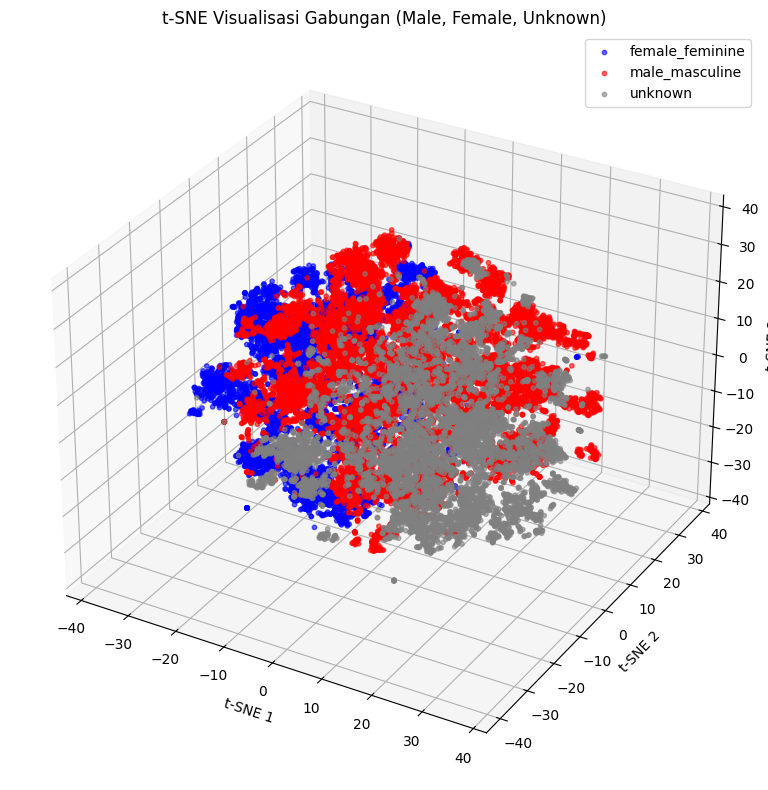


Rata-rata MFCC (24 koefisien) per kelas:
Koefisien | Female | Male | Unknown
---------|--------|------|--------
   1     | -585.493 | -591.535 | -608.253
   2     | 16.867 | 31.942 | 28.556
   3     | -23.006 | -20.028 | -10.779
   4     | 14.889 |  9.890 |  9.429
   5     | -26.238 | -19.991 | -10.675
   6     | -3.164 | -0.412 | -3.982
   7     | -15.551 | -13.064 | -12.595
   8     | -7.035 | -6.136 | -7.363
   9     | -9.344 | -8.823 | -6.317
  10     | -7.827 | -2.196 | -2.706
  11     | -13.754 | -9.580 | -7.093
  12     | -7.641 | -2.401 | -3.940
  13     | -4.939 | -8.022 | -7.629
  14     | -7.280 |  1.665 |  2.899
  15     | -10.079 | -9.596 | -12.213
  16     | -3.552 | -0.430 |  0.249
  17     | -10.002 | -7.570 | -7.950
  18     | -3.767 | -0.811 | -0.959
  19     | -8.160 | -7.090 | -7.230
  20     | -4.608 | -0.114 | -0.445
  21     | -6.129 | -6.573 | -7.824
  22     | -1.963 |  0.564 |  0.053
  23     | -4.676 | -4.214 | -5.942
  24     |  1.287 | -0.495 | -0.854

===

In [20]:
# ==========================================
# STEP 17: EKSTRAKSI UNTUK DATA UNKNOWN (GENDER KOSONG)
# ==========================================

# Ambil data dengan gender kosong (NaN atau string kosong)
df_unknown = df[df['gender'].isna()].copy()
print(f"Jumlah data unknown awal: {len(df_unknown)}")

# Validasi file audio
valid_unknown_paths = []
for idx, row in df_unknown.iterrows():
    audio_path = os.path.join(audio_folder, row['path'])
    if os.path.exists(audio_path):
        valid_unknown_paths.append(idx)

df_unknown = df_unknown.loc[valid_unknown_paths].reset_index(drop=True)
print(f"Jumlah data unknown setelah validasi file: {len(df_unknown)}")

# Ekstrak fitur untuk data unknown (gunakan parameter yang sama)
X_unknown = []
for idx, row in df_unknown.iterrows():
    audio_path = os.path.join(audio_folder, row['path'])
    features = extract_mfcc(
        audio_path,
        n_mfcc=N_MFCC,
        target_sr=TARGET_SR,
        pre_emphasis=PRE_EMPHASIS,
        win_length=WIN_LENGTH,
        hop_length=HOP_LENGTH,
        n_fft=N_FFT
    )
    if features is not None:
        X_unknown.append(features)

X_unknown = np.array(X_unknown)
print(f"Jumlah fitur unknown yang berhasil diekstrak: {X_unknown.shape[0]}")

# ==========================================
# STEP 18: GABUNGKAN DENGAN DATA YANG SUDAH ADA
# ==========================================

# Gabungkan fitur
X_all = np.vstack([X, X_unknown])  # X adalah fitur male+female dari STEP 7

# Buat label: 0=female, 1=male, 2=unknown
# y_encoded asli: 0=female, 1=male (dari LabelEncoder)
y_all = np.concatenate([
    y_encoded,                     # 0 dan 1
    np.full(X_unknown.shape[0], 2) # 2 untuk unknown
])

print(f"Total data gabungan: {X_all.shape[0]}")
print(f"Distribusi label: female={np.sum(y_all==0)}, male={np.sum(y_all==1)}, unknown={np.sum(y_all==2)}")

# ==========================================
# STEP 19: STANDARISASI FITUR GABUNGAN
# ==========================================

scaler_all = StandardScaler()
X_all_scaled = scaler_all.fit_transform(X_all)

# ==========================================
# STEP 20: REDUKSI DIMENSI DENGAN PCA (OPSIONAL, UNTUK MEMPERCEPAT t-SNE)
# ==========================================

from sklearn.decomposition import PCA

# PCA tidak boleh lebih besar dari jumlah fitur yang tersedia.
# Karena X_all_scaled punya 24 fitur (MFCC=24), maka n_components maksimal adalah 24.
max_components = min(50, X_all_scaled.shape[1], X_all_scaled.shape[0] - 1)
pca = PCA(n_components=max_components, random_state=42)
X_pca = pca.fit_transform(X_all_scaled)
print(f"Jumlah komponen PCA: {max_components}")
print(f"Varians terkumpul: {pca.explained_variance_ratio_.sum():.4f}")

# ==========================================
# STEP 21: t-SNE UNTUK VISUALISASI 3D
# ==========================================

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Karena data besar, kita bisa subsample untuk kecepatan (opsional)
# Ambil sampel proporsional dari setiap kelas (misal 2000 per kelas)
# Atau bisa jalankan semua (mungkin lambat). Saya sarankan subsample 5000 total.

# Gunakan seluruh data gabungan, bukan sampling
X_sample = X_pca
y_sample = y_all

print(f"Ukuran data t-SNE: {len(X_sample)}")

# Jalankan t-SNE dengan seluruh data gabungan
# Gunakan max_iter karena versi scikit-learn saat ini tidak menerima n_iter lagi.
tsne = TSNE(
    n_components=3,
    random_state=42,
    perplexity=30,
    max_iter=1000,
    init='pca'
)
X_tsne = tsne.fit_transform(X_sample)

# Plot 3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

colors = ['blue', 'red', 'gray']
labels = ['female_feminine', 'male_masculine', 'unknown']

for i, label in enumerate([0, 1, 2]):
    idx = y_sample == label
    ax.scatter(X_tsne[idx, 0], X_tsne[idx, 1], X_tsne[idx, 2],
               c=colors[i], label=labels[i], alpha=0.6, s=10)

ax.set_title('t-SNE Visualisasi Gabungan (Male, Female, Unknown)')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_zlabel('t-SNE 3')
ax.legend()
plt.tight_layout()
plt.savefig('tsne_3d_all_genders.png', dpi=300)
plt.show()

# ==========================================
# STEP 22: PERBANDINGAN RATA-RATA MFCC PER KELAS (OPSIONAL)
# ==========================================

# Hitung rata-rata koefisien MFCC untuk tiap kelas
mean_male = np.mean(X[y_encoded == 1], axis=0)
mean_female = np.mean(X[y_encoded == 0], axis=0)
mean_unknown = np.mean(X_unknown, axis=0)

# Tampilkan sebagai tabel sederhana
print("\nRata-rata MFCC (24 koefisien) per kelas:")
print("Koefisien | Female | Male | Unknown")
print("---------|--------|------|--------")
for i in range(N_MFCC):
    print(f"  {i+1:2d}     | {mean_female[i]:6.3f} | {mean_male[i]:6.3f} | {mean_unknown[i]:6.3f}")

# ==========================================
# STEP 23: ANALISIS KESIMPULAN EKSPLORATIF
# ==========================================

print("\n=== Analisis Eksploratif Data Unknown ===")
print("Berdasarkan visualisasi t-SNE dan rata-rata MFCC, data unknown (gender kosong) tidak menunjukkan pemisahan yang jelas sebagai cluster tersendiri. Sebagian besar titik unknown tumpang tindih dengan sebaran female dan male, menandakan bahwa karakteristik spektral mereka mirip dengan kedua kelas yang ada.")
print("Oleh karena itu, data unknown tidak dapat digunakan sebagai kelas ketiga dalam supervised learning karena tidak memiliki ground truth, dan secara eksploratif tidak memperlihatkan pola unik yang signifikan.")